<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML321ENSkillsNetwork817-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Course Rating Prediction using Neural Networks**


## **Introduction**
In previous labs 6.2, we built recommender systems using user features and item features that were defined manually.
For example, given a user `i`, we may build its profile feature vector and course rating feature vector, and given an item `j`, we may create its genre vector and user enrollment vectors.


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/module_4/images/explicit_user_item_features.png)


Using these explicit feature vectors, we can perform machine learning tasks such as computing similarities between users or items, identifying nearest neighbors, and estimating rating values using dot products.

The main advantage of explicit features is that they are highly interpretable and often provide strong performance.
The main drawback is that considerable effort is required to design, construct, and store these feature vectors.

### **Idea of this lab**

In this lab, we will use a different approach. Instead of manually defining features, we will train a neural network to **learn the features automatically**.

The neural network model takes two inputs from the rating dataset: user ID, item ID, and converts them into embedding features, and prediction of course rating as the output. \
`user ID` + `item ID` ─► `embedding` ─► `dense layers` ─► `rating` 

User IDs and item IDs by themselves are just numbers without meaningful values. 
We create an embedding layer in the model to turns **each ID** into a learned dense vector, then feed them into hidden layers, so the network learns its values during training.

- `user ID` ─► one-hot encoding ─► embedding features ─► u (dense vector)
- `item ID` ─► one-hot encoding ─► embedding features ─► v (dense vector)

An embedding layer is almost like a smart first layer for categorical variables.
- do not treat IDs as ordinary numbers
- do not waste memory on giant one-hot vectors
- instead, directly learn a compact vector for each category

Embedding layers allow the model to learn hidden features, such as: user preferences, item properties.

These hidden features help the model make better predictions for course rating (output).

### **Learning Latent Features with Embedding Layers**
We want the model to predict how user $u$ would rate item $i$:

$\hat{r}_{ui} = \text{predicted rating of user } u \text{ on item } i$

The key idea is to let the model learn compact feature vectors for users and items. These learned vectors are called **latent features** because they are not manually defined. Instead, they are discovered from rating patterns during training.

####  **Step 1 — Input (User & Item IDs)**

The data starts with two identifiers: a user ID $u$ and an item ID $i$. These IDs are categories, not numerical measurements, so the model should not treat user 20 as twice user 10. A safer representation is a one-hot vector, where only the position for the selected user or item is turned on.

$\mathbf{x}_u = [0,0,1,0,\dots,0] \in \mathbb{R}^{N_{\text{users}}}$

$N_{\text{users}}$ = number of users

$\mathbf{x}_i = [0,1,0,0,\dots,0] \in \mathbb{R}^{N_{\text{items}}}$

$N_{\text{items}}$ = number of items

Only one entry equals 1 in each vector. That entry identifies the user or item, and all other entries are 0.


####  **Step 2 — User and Item Embeddings**
One-hot vectors are easy to understand, but they are very large and mostly zeros. An embedding layer replaces each sparse vector with a smaller dense vector. This dense vector is what the model learns during training.

For users, the embedding layer stores a matrix with one row per user:

$\mathbf{W_u \in \mathbb{R}^{N_{\text{users}} \times k}}$

$k$ = embedding size

$
\mathbf{W_u} =
\begin{bmatrix}
0.2 & 0.5 & \dots \\  
0.9 & 0.3 & \dots \\
0.8 & 0.2 & \dots \\
\dots & \dots & \dots
\end{bmatrix}
$

Rows correspond to: user 1, user 2, user 3

Multiplying the one-hot user vector by this matrix simply selects the row for user $u$. That row becomes the user embedding vector $\mathbf{p}_u$.

$$
\mathbf{p}_u = \mathbf{x}_u\cdot\mathbf{W}_u= \mathbf{W}_u[u]
$$     


$$
[0,0,1,0,\dots,0] \times \begin{bmatrix} 0.2 & 0.5 & \dots \\ 0.9 & 0.3 & \dots \\ 0.8 & 0.2 & \dots \\ \dots & \dots & \dots \end{bmatrix} = [0.8, 0.2,\dots]
$$

Items use the same idea. The item embedding layer stores one row per item:

$\mathbf{W_i \in \mathbb{R}^{N_{\text{items}} \times k}}$

$
\mathbf{W_i} =
\begin{bmatrix}
0.1 & 0.4 & \dots \\  
0.7 & 0.4 & \dots \\
0.3 & 0.5 & \dots \\
\dots & \dots & \dots
\end{bmatrix}
$

Rows correspond to: item 1, item 2, item 3

The selected item row becomes the item embedding vector $\mathbf{q}_i$.

$$
\mathbf{q}_i = \mathbf{x}_i\cdot\mathbf{W}_i= \mathbf{W}_i[i]
$$     

$$
[0,1,0,0,\dots,0] \times \begin{bmatrix} 0.2 & 0.5 & \dots \\ 0.9 & 0.3 & \dots \\ 0.8 & 0.2 & \dots \\ \dots & \dots & \dots \end{bmatrix} = [0.5, 0.3, 0.2, ...]
$$

After this step, each user and each item is represented by a learned dense vector instead of a long sparse ID vector.


####  **Step 3 — Model Formulation**
Once we have a user vector and an item vector, the model needs to turn them into a rating prediction. A simple way to measure how well they match is to compute their dot product and then add bias terms.

$$
z = \mathbf{p}_u \cdot \mathbf{q}_i + b_u + b_i
$$ 

Here, $\mathbf{p}_u \cdot \mathbf{q}_i$ measures the interaction between the user and the item. The user bias $b_u$ captures whether a user tends to rate higher or lower than average, while the item bias $b_i$ captures whether an item tends to receive higher or lower ratings overall.

Geometrically, the dot product between two vectors is determined by their lengths and the angle between them:$$\mathbf{p}_u \cdot \mathbf{q}_i = \|\mathbf{p}_u\| \|\mathbf{q}_i\| \cos(\theta)$$

To allow the model to represent nonlinear behavior, we apply an activation function:

$$
\hat{r}_{ui} = \text{ReLU}(z)  \quad\quad\quad   
\text{ReLU}(z) = \max(0, z)
$$

Putting the pieces together gives the final prediction:

$$
\hat{r}_{ui} = \text{ReLU}(\mathbf{p}_u \cdot \mathbf{q}_i + b_u + b_i)
$$

During training, the model compares the true rating $r_{ui}$ with the predicted rating $\hat{r}_{ui}$:

$$
e_{ui} = r_{ui} - \hat{r}_{ui}
$$

The loss adds the squared error across all observed user-item rating pairs:

$$
L = \sum_{(u,i)} (e_{ui})^2 = \sum_{(u,i)} (r_{ui} - \hat{r}_{ui})^2 = \sum_{(u,i)} (r_{ui} - \text{ReLU}(z))^2 = \sum_{(u,i)} (r_{ui} - \text{ReLU}(\mathbf{p}_u \cdot \mathbf{q}_i+ b_u + b_i))^2
$$


#### **Step 4 — Gradient Descent**

Training means adjusting the embeddings and bias terms so that the loss becomes smaller. Gradient descent updates each parameter in the direction that reduces the loss.

$$
\text{parameter} \leftarrow \text{parameter} - \eta \cdot \frac{\partial L}{\partial \text{parameter}}
$$

In this rule, $\eta$ is the learning rate, and $\frac{\partial L}{\partial \text{parameter}}$ is the gradient of the loss with respect to the parameter.

The same update rule is applied to the user embeddings, item embeddings, and bias terms:

$$
\mathbf{p}_u \leftarrow \mathbf{p}_u - \eta \cdot \frac{\partial L}{\partial \mathbf{p}_u}
$$

$$
\mathbf{q}_i \leftarrow \mathbf{q}_i - \eta \cdot \frac{\partial L}{\partial \mathbf{q}_i}
$$

$$
b_u \leftarrow b_u - \eta \cdot \frac{\partial L}{\partial b_u}
$$

$$
b_i \leftarrow b_i - \eta \cdot \frac{\partial L}{\partial b_i}
$$

To see where the update for the user embedding comes from, apply the chain rule:

$$\frac{\partial L}{\partial \mathbf{p}_u} = \frac{\partial L}{\partial e_{ui}}
\cdot
\frac{\partial e_{ui}}{\partial \hat{r}_{ui}}
\cdot
\frac{\partial \hat{r}_{ui}}{\partial z}
\cdot
\frac{\partial z}{\partial \mathbf{p}_u}
$$


$$\frac{\partial L}{\partial e_{ui}} = 2 e_{ui} \quad\quad\quad    

\frac{\partial e_{ui}}{\partial \hat{r}_{ui}} = -1 \quad\quad\quad  

\frac{\partial \hat{r}_{ui}}{\partial z} =
\begin{cases}
1 & z > 0 \\
0 & z \le 0
\end{cases}  \quad\quad\quad 

\frac{\partial z}{\partial \mathbf{p}_u} = \mathbf{q}_i
$$

Combining these terms gives:

$$\frac{\partial L}{\partial \mathbf{p}_u}
= (2 e_{ui}) \cdot (-1) \cdot
(\mathbf{1}_{z > 0}) \cdot (\mathbf{q}_i) = -2 e_{ui} \cdot \mathbf{q}_i
$$

The user bias follows the same chain rule, except $z$ changes by 1 when $b_u$ changes:

$$\frac{\partial L}{\partial b_u} =
\frac{\partial L}{\partial e_{ui}}
\cdot
\frac{\partial e_{ui}}{\partial \hat{r}_{ui}}
\cdot
\frac{\partial \hat{r}_{ui}}{\partial z}
\cdot
\frac{\partial z}{\partial b_u}
$$

$$
\frac{\partial z}{\partial b_u} = 1
$$

$$
\frac{\partial L}{\partial b_u}
= (2 e_{ui}) \cdot (-1) \cdot
(\mathbf{1}_{z > 0}) \cdot (1) = -2 e_{ui}
$$

After substituting these gradients into the update rule, the user vector update becomes:

$$
\mathbf{p}_u \leftarrow \mathbf{p}_u - \eta \cdot (-2 e_{ui} \cdot \mathbf{q}_i)
$$

The constant factor can be absorbed into a new learning rate $\eta'$:

$$
\mathbf{p}_u \leftarrow \mathbf{p}_u + \eta' \cdot  e_{ui} \cdot \mathbf{q}_i
$$

The item vector and bias terms update in the same spirit:

$$
\mathbf{q}_i \leftarrow \mathbf{q}_i + \eta' \cdot e_{ui} \cdot \mathbf{p}_u
$$

$$
b_u \leftarrow b_u + \eta' \cdot  e_{ui}
$$

$$
b_i \leftarrow b_i + \eta' \cdot  e_{ui}
$$


####  **Step 5 — Training Outcomes**

The training signal comes from the prediction error:

$$
e_{ui} = r_{ui} - \hat{r}_{ui}
$$


$$
\hat{r}_{ui} = \mathbf{p}_u \cdot \mathbf{q}_i
$$

Geometrically, the dot product between two vectors is determined by their lengths and the angle between them:$$\mathbf{p}_u \cdot \mathbf{q}_i = \|\mathbf{p}_u\| \|\mathbf{q}_i\| \cos(\theta)$$

If the prediction is too low, then $e_{ui} > 0$. The update increases the dot product by moving the user vector more toward the item vector. As the angle $\theta$ decreases, the model becomes more likely to predict a higher rating for this user-item pair.

If the prediction is too high, then $e_{ui} < 0$. The update has the opposite effect: it reduces the dot product by moving the vectors farther apart. As the angle $\theta$ increases, the model becomes more likely to predict a lower rating.

Over many ratings, these small updates organize the embedding space. Users with similar rating behavior tend to end up with related embeddings, and items liked by similar users tend to become closer in the learned latent space.


### **Goal of this lab**
1. Convert user IDs and item IDs into integer indices
2. Build a neural network with embedding layers
3. Train the model to predict ratings
4. Evaluate the model performance
5. Extract the user and item latent features

The user and item latent features can be used later for other models.

## **Objectives**


In this lab, we will be training neural networks to predict course ratings while simultaneously extracting users' and items' latent features. 


* Use `tensorflow` to train neural networks to extract the user and item latent features from the hidden's layers  
* Predict course ratings with trained neural networks


----


### **Prepare and setup lab environment**


Install tensorflow 2.7 if not installed before in your Python environment


In [92]:
#!pip install tensorflow==2.7.0

and import required libraries:


In [93]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

import keras
from keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# If you want to disable GPU, keep this line
tf.config.set_visible_devices([], "GPU")

In [94]:
# also set a random state
rs = 123

### **Load and processing rating dataset**


In [95]:
rating_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/ratings.csv"
rating_df = pd.read_csv(rating_url)
rating_df.head()

,user,item,rating
0,1889878,CC0101EN,3.0
1,1342067,CL0101EN,3.0
2,1990814,ML0120ENv3,3.0
3,380098,BD0211EN,3.0
4,779563,DS0101EN,3.0


This is the same rating dataset we have been using in previous lab, which contains the three main columns: `user`, `item`, and `rating`. 


Next, let's figure out how many unique users and items, their total numbers will determine the sizes of one-hot encoding vectors.


In [ ]:
num_users = len(rating_df["user"].unique())
num_items = len(rating_df["item"].unique())
print(f"There are total `{num_users}` of users and `{num_items}` items")

There are total `33901` of users and `126` items


It means our each user can be represented as a `33901 x 1` one-hot vector and each item can be represented as `126 x 1` one-hot vector.


#### **The model idea**
The goal is to create a neural network structure that can take the user and item one-hot vectors as inputs and outputs a rating estimation or the probability of interaction (such as the probability of completing a course). 

While training and updating the weights in the neural network, its hidden layers should be able to capture the pattern or features for each user and item. Based on this idea, we can design a simple neural network architecture like the following:


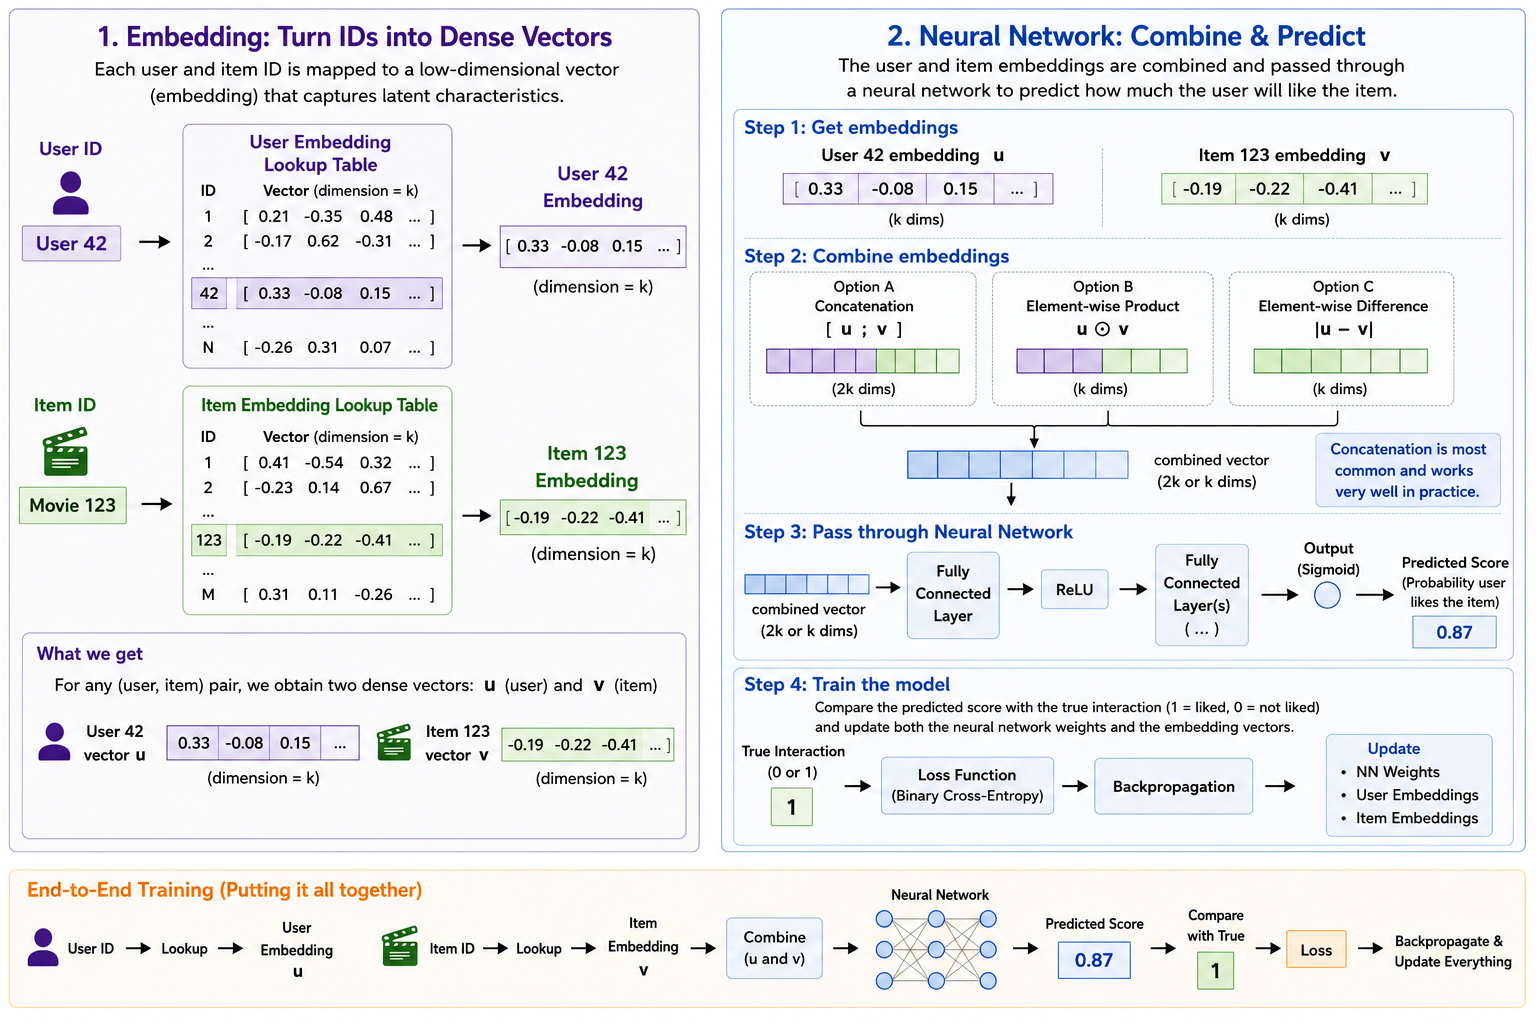

The network inputs are two one-hot encoding vectors, the blue one is for the user and the green one is for the item. Then on top of them, we added two embedding layers. Here *embedding means embedding the one-hot encoding vector into a latent feature space*. The embedding layer is a fully-connected layer that outputs the embedding feature vectors. For example, the user embedding layer takes `33901 x 1` one-hot vector as input and outputs a `16 x 1` embedding vector.


*The embedding layer outputs two embedding vectors, which are similar to Non-negative matrix factorization. Then we could simply dot the product the user and item embedding vector to output a rating estimation.*


### **Implementing the recommender neural network using tensorflow**


This network architecture could be defined and implemented as a sub-class inheriting the `tensorflow.keras.Model` super class, let's call it `RecommenderNet()`.


#### **Subclassing API**

**Model structure**: matrix factorization with bias

`rating = dot(user_embedding, item_embedding) + user_bias + item_bias`

1. Embedding (interaction term): `dot(user_vector, item_vector)` \
   captures personalized preference: "this user likes action movies", "this item is action movie"

2. User bias: `user_bias[user_id]`
   captures some users always rate higher/lower: "User A average = 4.5", "User B average = 2.5"

3. Item bias: `item_bias[item_id]`
   captures some items are globally popular/unpopular: "Movie X average = 4.8", "Movie Y average = 2.0"

4. If we remove bias, the model must learn everything through embeddings. This makes learning: harder, slower
and less accurate 
    
| Component | What it learns       |
| --------- | -------------------- |
| Bias      | simple global trends |
| Embedding | complex interactions |
   

In [ ]:
class RecommenderNet(keras.Model):  # inherits from keras.Model

    def __init__(self, num_users, num_items, embedding_size=16, **kwargs):
        """
        Constructor
        :param int num_users: number of users
        :param int num_items: number of items
        :param int embedding_size: the size of embedding vector
        """
        super(RecommenderNet, self).__init__(
            **kwargs
        )  # Call parent constructor
        self.num_users = num_users  # how many users in dataset
        self.num_items = num_items  # how many items
        self.embedding_size = embedding_size  # length of embedding vector

        # Define a user_embedding vector
        # Input dimension is the num_users
        # Output dimension is the embedding size
        self.user_embedding_layer = layers.Embedding(
            input_dim=num_users,
            output_dim=embedding_size,
            name="user_embedding_layer",
            embeddings_initializer="he_normal",
            embeddings_regularizer=keras.regularizers.l2(1e-6),
        )

        # Define a user bias layer
        # Bias is applied per user, hence output_dim is set to 1.
        self.user_bias = layers.Embedding(
            input_dim=num_users, output_dim=1, name="user_bias"
        )

        # Define an item_embedding vector
        # Input dimension is the num_items
        # Output dimension is the embedding size
        self.item_embedding_layer = layers.Embedding(
            input_dim=num_items,
            output_dim=embedding_size,
            name="item_embedding_layer",
            embeddings_initializer="he_normal",
            embeddings_regularizer=keras.regularizers.l2(1e-6),
        )

        # Define an item bias layer
        # Bias is applied per item, hence output_dim is set to 1.
        self.item_bias = layers.Embedding(
            input_dim=num_items, output_dim=1, name="item_bias"
        )

        # self.hidden1 = layers.Dense(64, activation="relu", name="hidden_dense_1")
        # self.dropout1 = layers.Dropout(0.3)
        # self.hidden2 = layers.Dense(64, activation="relu", name="hidden_dense_2")
        self.output_layer = layers.Dense(
            1, activation="relu", name="output_layer"
        )

    def call(self, inputs):
        """
        method to be called during model fitting

        :param inputs: user and item one-hot vectors
        """
        # Compute the user embedding vector
        username = self.user_embedding_layer(inputs[:, 0])
        user_bias = self.user_bias(inputs[:, 0])
        course_id = self.item_embedding_layer(inputs[:, 1])
        item_bias = self.item_bias(inputs[:, 1])

        dot_user_item = tf.reduce_sum(
            username * course_id, axis=1, keepdims=True
        )
        # Add all the components (including bias)
        x = dot_user_item + user_bias + item_bias
        # x = self.hidden1(x)
        # x = self.dropout1(x)
        # x = self.hidden2(x)
        x = self.output_layer(x)

        return x

#### **Train and evaluate the RecommenderNet()**


Now it's time to train and evaluate the defined `RecommenderNet()`. First, we need to process the original rating dataset a little bit by converting the actual user ids and item ids into integer indices for `tensorflow` to creating the one-hot encoding vectors.


In [ ]:
def process_dataset(raw_data):
    # Make a copy of the original data (not clear why we need this)
    encoded_data = raw_data.copy()

    # Mapping user ids to indices
    user_list = encoded_data["user"].unique().tolist()
    user_id2idx_dict = {x: i for i, x in enumerate(user_list)}
    user_idx2id_dict = {i: x for i, x in enumerate(user_list)}

    # Mapping course ids to indices
    course_list = encoded_data["item"].unique().tolist()
    course_id2idx_dict = {x: i for i, x in enumerate(course_list)}
    course_idx2id_dict = {i: x for i, x in enumerate(course_list)}

    # Convert original user ids to idx
    encoded_data["user"] = encoded_data["user"].map(user_id2idx_dict)
    # Convert original course ids to idx
    encoded_data["item"] = encoded_data["item"].map(course_id2idx_dict)
    # Convert rating to int
    encoded_data["rating"] = encoded_data["rating"].values.astype("int")

    return encoded_data, user_idx2id_dict, course_idx2id_dict

In [99]:
encoded_data, user_idx2id_dict, course_idx2id_dict = process_dataset(rating_df)

In [100]:
encoded_data.head()

,user,item,rating
0,0,0,3
1,1,1,3
2,2,2,3
3,3,3,3
4,4,4,3


Then we can split the encoded dataset into training and testing datasets.


In [ ]:
def generate_train_test_datasets(dataset, scale=True):

    # Features
    x = dataset[["user", "item"]].values
    y = dataset["rating"].values.reshape(-1, 1)  # make it 2D for scaler

    # Step 1: split train (80%) and temp (20%)
    x_train, x_temp, y_train, y_temp = train_test_split(
        x, y, test_size=0.2, random_state=42
    )

    # Step 2: split temp into val (10%) and test (10%)
    x_val, x_test, y_val, y_test = train_test_split(
        x_temp, y_temp, test_size=0.5, random_state=42
    )

    # prevent data leakage: fit scaler ONLY on training data
    if scale:
        scaler = MinMaxScaler()
        y_train = scaler.fit_transform(y_train)
        y_val = scaler.transform(y_val)
        y_test = scaler.transform(y_test)

    return x_train, x_val, x_test, y_train, y_val, y_test

In [ ]:
x_train, x_val, x_test, y_train, y_val, y_test = generate_train_test_datasets(
    encoded_data
)

If we take a look at the training input data, it is simply just a list of user indices and item indices, which is a dense format of one-hot encoding vectors.


In [103]:
user_indices = x_train[:, 0]
user_indices

array([19371, 20064, 14884, ...,  2999, 11082,  4824])

In [104]:
item_indices = x_train[:, 1]
item_indices

array([70, 17,  5, ..., 66, 56,  4])

and training output labels are a list of 0s and 1s indicating if the user has completed a course or not.


In [105]:
y_train

array([[0.],
       [1.],
       [1.],
       ...,
       [1.],
       [1.],
       [1.]])

Then we can choose a small embedding vector size to be 16 and create a `RecommenderNet()` model to be trained


In [106]:
embedding_size = 16
model = RecommenderNet(num_users, num_items, embedding_size)

_TODO: Train the RecommenderNet() model_


Epoch 1/10
2917/2917 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0971 - root_mean_squared_error: 0.3111 - val_loss: 0.0194 - val_root_mean_squared_error: 0.1369
Epoch 2/10
2917/2917 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0108 - root_mean_squared_error: 0.0998 - val_loss: 0.0158 - val_root_mean_squared_error: 0.1213
Epoch 3/10
2917/2917 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0064 - root_mean_squared_error: 0.0730 - val_loss: 0.0153 - val_root_mean_squared_error: 0.1193
Epoch 4/10
2917/2917 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0051 - root_mean_squared_error: 0.0633 - val_loss: 0.0153 - val_root_mean_squared_error: 0.1192
Epoch 5/10
2917/2917 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0046 - root_mean_squared_error: 0.0596 - val_loss: 0.0151 - val_root_mean_squared_error: 0.1187
Epoch 6/10
2917/2917 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0043 - root_mean_squared_error: 0.0576 - val_loss: 0.0149 - val_root_mean_squared_error: 0.1182
Epoch 7/10
2917/2917 ━━━━━━━━━━━━━━━━━━━

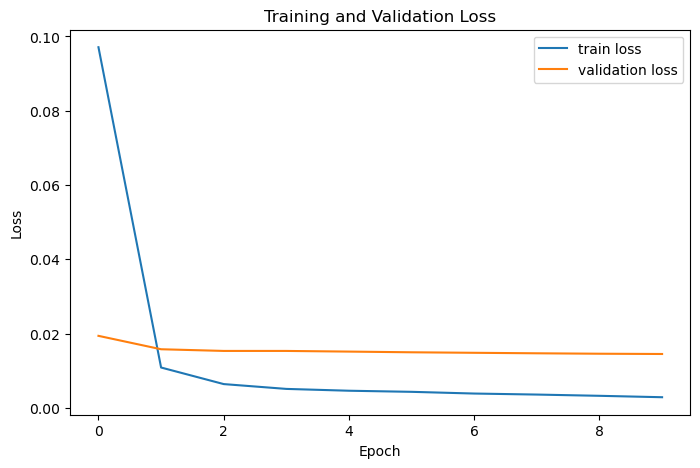

In [ ]:
## - call model.compile() method to set up the loss and optimizer and metrics for the model training, you may use
##  - - tf.keras.losses.MeanSquaredError() as training loss
##  - - keras.optimizers.Adam() as optimizer
##  - - tf.keras.metrics.RootMeanSquaredError() as metric

## - call model.fit() to train the model

## - optionally call model.save() to save the model

## - plot the train and validation loss

model.compile(
    loss=tf.keras.losses.MeanSquaredError(),
    optimizer=keras.optimizers.Adam(),
    metrics=[tf.keras.metrics.RootMeanSquaredError()],
)

history = model.fit(
    x=x_train,
    y=y_train,
    batch_size=64,
    epochs=10,
    validation_data=(x_val, y_val),
    verbose=1,
)

# Optional: save the trained model
# model.save("recommender_net.keras")

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

<details>
    <summary>Click here for Hints</summary>
    
When you are fitting a model, dont forget to specify the parameters: `x=x_train, y=y_train`, as well as `batch_size=64`, number of `epochs=10` and of course `validation_data=(x_val, y_val)` you can also define `verbose = 1` which will show you an animated progress for the training progress for each epoch.
    
* You can set  `history = model.fit()` which will give you a "loss" dataframe which will be very useful for ploting the train and validation loss. To plot it, use plt.plot() with `history.history["loss"]` as its parameter for train loss and `history.history["val_loss"]` for validation loss.


_TODO:_ Evaluate the trained model


In [108]:
### - call model.evaluate() to evaluate the model
test_results = model.evaluate(x_test, y_test, verbose=1)
print("Test results:", test_results)

730/730 ━━━━━━━━━━━━━━━━━━━━ 0s 379us/step - loss: 0.0145 - root_mean_squared_error: 0.1175
Test results: [0.014470131136476994, 0.11751626431941986]


<details>
    <summary>Click here for Hints</summary>
    
Use `x_test, y_test` as parameters for `model.evaluate()`


#### **Extract the user and item embedding vectors as latent feature vectors**


Now, we have trained the `RecommenderNet()` model and it can predict the ratings with relatively small RMSE. 

If we print the trained model then we can see its layers and their parameters/weights.


In [109]:
model.summary()

Model: "recommender_net_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ user_embedding_layer            │ (None, 16)             │       542,416 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ user_bias (Embedding)           │ (None, 1)              │        33,901 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ item_embedding_layer            │ (None, 16)             │         2,016 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ item_bias (Embedding)           │ (None, 1)              │           126 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,735,385 (6.62 MB)

 Trainable params: 578,461 (2.21 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,156,924 (4.41 MB)

In the `RecommenderNet`, the `user_embedding_layer` and `item_embedding_layer` layers contain the trained weights. Essentially, they are the latent user and item features learned by `RecommenderNet` and will be used to predict the interaction. As such, while training the neural network to predict rating, the embedding layers are simultaneously trained to extract the embedding user and item features.


We can easily get the actual weights using `model.get_layer().get_weights()` methods


In [ ]:
# User features
user_latent_features = model.get_layer("user_embedding_layer").get_weights()[0]
print(f"User features shape: {user_latent_features.shape}")

User features shape: (33901, 16)


In [111]:
user_latent_features[0]

array([ 0.02230955,  0.02573992, -0.04269807,  0.00629101, -0.02189962,
       -0.04083583,  0.07034481,  0.00391788, -0.02686076, -0.02538434,
       -0.06405728, -0.04821429, -0.00840594, -0.04162386,  0.00977742,
        0.04768875], dtype=float32)

In [ ]:
item_latent_features = model.get_layer("item_embedding_layer").get_weights()[0]
print(f"Item features shape: {item_latent_features.shape}")

Item features shape: (126, 16)


In [113]:
item_latent_features[0]

array([-0.01631763,  0.00816845,  0.00324224,  0.00939905, -0.04419297,
        0.02241082,  0.12571692,  0.00908075,  0.02579316,  0.03488994,
       -0.10812969, -0.07207724, -0.02818339,  0.01552331,  0.02672566,
       -0.02999824], dtype=float32)

Now, each user of the total 33901 users has been transformed into a 16 x 1 latent feature vector and each item of the total 126 has been transformed into a 16 x 1 latent feature vector.


#### **Customize the RecommenderNet to potentially improve the model performance**


The pre-defined `RecommenderNet()` is a actually very basic neural network, you are encouraged to customize it to see if model prediction performance will be improved. Here are some directions:
- Hyperparameter tuning, such as the embedding layer dimensions
- Add more hidden layers
- Try different activation functions such as `ReLu`


In [ ]:
## Update RecommenderNet() class

## compile and fit the updated model

## evaluate the updated model


class RecommenderNetV2(keras.Model):
    def __init__(
        self,
        num_users,
        num_items,
        embedding_size=16,
        activation="relu",
        **kwargs
    ):
        """
        Constructor
        :param int num_users: number of users
        :param int num_items: number of items
        :param int embedding_size: the size of embedding vector
        """
        super(RecommenderNetV2, self).__init__(**kwargs)
        self.num_users = num_users  # how many users in dataset
        self.num_items = num_items  # how many items
        self.embedding_size = embedding_size  # length of embedding vector

        # Define a user_embedding vector
        # Input dimension is the num_users
        # Output dimension is the embedding size
        self.user_embedding_layer = layers.Embedding(
            input_dim=num_users,
            output_dim=embedding_size,
            name="user_embedding_layer_v2",
            embeddings_initializer="he_normal",
            embeddings_regularizer=keras.regularizers.l2(1e-6),
        )

        # Define a user bias layer
        self.user_bias = layers.Embedding(
            input_dim=num_users,
            output_dim=1,
            name="user_bias_v2",
        )

        # Define an item_embedding vector
        # Input dimension is the num_items
        # Output dimension is the embedding size
        self.item_embedding_layer = layers.Embedding(
            input_dim=num_items,
            output_dim=embedding_size,
            name="item_embedding_layer_v2",
            embeddings_initializer="he_normal",
            embeddings_regularizer=keras.regularizers.l2(1e-6),
        )

        # Define an item bias layer
        self.item_bias = layers.Embedding(
            input_dim=num_items,
            output_dim=1,
            name="item_bias_v2",
        )

        self.output_layer = layers.Dense(
            1, activation=activation, name="output_layer"
        )

    def call(self, inputs):
        """
        method to be called during model fitting

        :param inputs: user and item one-hot vectors
        """
        # Compute the user embedding vector
        username = self.user_embedding_layer(inputs[:, 0])
        user_bias = self.user_bias(inputs[:, 0])
        course_id = self.item_embedding_layer(inputs[:, 1])
        item_bias = self.item_bias(inputs[:, 1])

        # Sum across rows
        interaction = tf.reduce_sum(username * course_id, axis=1, keepdims=True)
        x = interaction + user_bias + item_bias
        # x = self.hidden1(x)
        # x = self.hidden2(x)
        x = self.output_layer(x)
        return x


updated_model = RecommenderNetV2(num_users, num_items, embedding_size=16)
updated_model.compile(
    loss=tf.keras.losses.MeanSquaredError(),
    optimizer=keras.optimizers.Adam(),
    metrics=[tf.keras.metrics.RootMeanSquaredError()],
)

updated_history = updated_model.fit(
    x=x_train,
    y=y_train,
    batch_size=64,
    epochs=10,
    validation_data=(x_val, y_val),
    verbose=1,
)

updated_test_results = updated_model.evaluate(x_test, y_test, verbose=1)
print("Updated model test results:", updated_test_results)

Epoch 1/10
2917/2917 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0766 - root_mean_squared_error: 0.2763 - val_loss: 0.0186 - val_root_mean_squared_error: 0.1348
Epoch 2/10
2917/2917 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0095 - root_mean_squared_error: 0.0942 - val_loss: 0.0163 - val_root_mean_squared_error: 0.1246
Epoch 3/10
2917/2917 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0062 - root_mean_squared_error: 0.0731 - val_loss: 0.0158 - val_root_mean_squared_error: 0.1221
Epoch 4/10
2917/2917 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0047 - root_mean_squared_error: 0.0620 - val_loss: 0.0154 - val_root_mean_squared_error: 0.1205
Epoch 5/10
2917/2917 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0042 - root_mean_squared_error: 0.0578 - val_loss: 0.0153 - val_root_mean_squared_error: 0.1202
Epoch 6/10
2917/2917 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0038 - root_mean_squared_error: 0.0552 - val_loss: 0.0152 - val_root_mean_squared_error: 0.1200
Epoch 7/10
2917/2917 ━━━━━━━━━━━━━━━━━━━

In [ ]:
updated_model.summary()

Model: "recommender_net_v2_59"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ user_embedding_layer_v2         │ (None, 16)             │       542,416 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ user_bias_v2 (Embedding)        │ (None, 1)              │        33,901 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ item_embedding_layer_v2         │ (None, 16)             │         2,016 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ item_bias_v2 (Embedding)        │ (None, 1)              │           126 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,735,385 (6.62 MB)

 Trainable params: 578,461 (2.21 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,156,924 (4.41 MB)

##### **Tune keys parameters in recommender model**

lr=0.001, emb=16, act=relu | val_rmse=0.1116
lr=0.001, emb=16, act=tanh | val_rmse=0.0884
lr=0.001, emb=32, act=relu | val_rmse=0.1145
lr=0.001, emb=32, act=tanh | val_rmse=0.0879
lr=0.01, emb=16, act=relu | val_rmse=0.1171
lr=0.01, emb=16, act=tanh | val_rmse=0.0822
lr=0.01, emb=32, act=relu | val_rmse=0.1155
lr=0.01, emb=32, act=tanh | val_rmse=0.0838
Best params: (16, 0.01, 'tanh')
Best validation RMSE: 0.08218531310558319


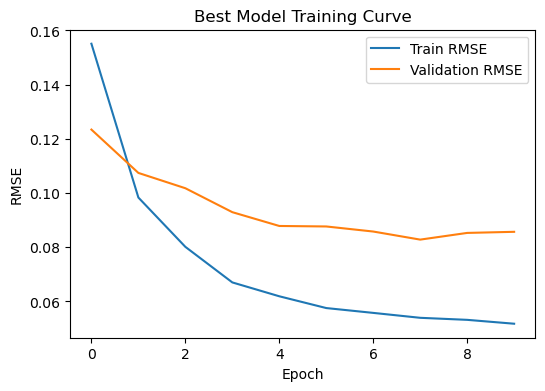

In [ ]:
def train_model(embedding_size, learning_rate, activation, epochs=10):

    model = RecommenderNetV2(
        num_users,
        num_items,
        embedding_size=embedding_size,
        activation=activation,
    )

    model.compile(
        loss="mse",
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=[tf.keras.metrics.RootMeanSquaredError()],
    )

    history = model.fit(
        x_train,
        y_train,
        batch_size=32,
        epochs=epochs,
        validation_data=(x_val, y_val),
        verbose=0,
    )

    val_rmse = history.history["val_root_mean_squared_error"][-1]

    return val_rmse, model, history


# Grid search
best_rmse = float("inf")
best_params = None
best_model = None

results = []

for lr in [0.001, 0.01]:
    for emb in [16, 32]:
        for act in ["relu", "tanh"]:

            val_rmse, model, history = train_model(emb, lr, act)

            print(
                f"lr={lr}, emb={emb}, act={act} | " f"val_rmse={val_rmse:.4f}"
            )

            results.append(
                {
                    "lr": lr,
                    "emb": emb,
                    "act": act,
                    "val_rmse": val_rmse,
                }
            )

            if val_rmse < best_rmse:
                best_rmse = val_rmse
                best_params = (emb, lr, act)
                best_model = model

print("Best params:", best_params)
print("Best validation RMSE:", best_rmse)

best_emb, best_lr, best_act = best_params
val_rmse, best_model, best_history = train_model(best_emb, best_lr, best_act)

plt.figure(figsize=(6, 4))
plt.plot(best_history.history["root_mean_squared_error"], label="Train RMSE")
plt.plot(
    best_history.history["val_root_mean_squared_error"], label="Validation RMSE"
)

plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Best Model Training Curve")
plt.legend()
plt.show()

In [117]:
ANN_results_df = pd.DataFrame(results).sort_values("val_rmse")
ANN_results_df["RMSE"] = ANN_results_df["val_rmse"].round(4)

print(ANN_results_df)

      lr  emb   act  val_rmse    RMSE
5  0.010   16  tanh  0.082185  0.0822
7  0.010   32  tanh  0.083788  0.0838
3  0.001   32  tanh  0.087923  0.0879
1  0.001   16  tanh  0.088440  0.0884
0  0.001   16  relu  0.111645  0.1116
2  0.001   32  relu  0.114505  0.1145
6  0.010   32  relu  0.115524  0.1155
4  0.010   16  relu  0.117118  0.1171


In [118]:
# After finding the best hyperparameters, you can train the model again and plot the validation RMSE curve
test_loss, test_rmse = best_model.evaluate(x_test, y_test, verbose=0)
print("Final test RMSE:", test_rmse)

Final test RMSE: 0.08403684943914413


## **Summary**


In this lab, we have learned and practiced predicting course ratings using neural networks. With a predefined and trained neural network, we can extract or embed users and items into latent feature spaces and further predict the interaction between a user and an item with the latent feature vectors.


## **Authors**


[Yan Luo](https://www.linkedin.com/in/yan-luo-96288783/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML321ENSkillsNetwork817-2022-01-01), Su Wu


## **Change Log**


|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2021-10-25|1.0|Yan|Created the initial version|
|2026-04-19 | Student modification |Su Wu | Added explanatory documentation, code comments, and minor code edits for coursework, learning, and portfolio development|


Copyright © 2021 IBM Corporation. All rights reserved.
